# Notebook 03 — Results Analysis (Full)

**Project:** Benchmarking Modern Multilingual Transformer Models for Malay-English Code-Switched Sentiment Analysis  
**Authors:** Joshua Joenathan Thomas (25141571) | Amit Kumar Gupta (25109952)  

## Coverage
All models across three methodology tiers:  
**Lexicon** (VADER, TextBlob, pysentimiento) → **Classical ML** (TF-IDF + SVM) → **Transformer** (XLM-R, XLM-T)  
mDeBERTa-v3 documented as a training failure — shown separately.

In [1]:
import sys
import sys
from pathlib import Path
_cwd = Path.cwd()
for _p in [_cwd / '../src', _cwd / '../3_Source', _cwd / 'src', _cwd / '3_Source']:
    if (_p / 'config.py').exists():
        sys.path.insert(0, str(_p.resolve()))
        break
else:
    raise ImportError('config.py not found -- run Jupyter from the project root or notebooks/ directory')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from config import RESULTS_DIR, MODELS

plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})

# Tier colours
TIER_COLORS = {
    'Lexicon':        '#95a5a6',
    'Classical ML':   '#7f8c8d',
    'Transformer':    '#2980b9',
    'LLM (few-shot)': '#f39c12',
}
# Per-model colour overrides (keys must match r['key'] from all_results.json)
MODEL_COLORS = {
    'vader':             '#bdc3c7',
    'textblob':          '#95a5a6',
    'pysentimiento_en':  '#7f8c8d',
    'sentilexm':         '#1abc9c',   # teal — bilingual primary
    'melex':             '#16a085',   # dark teal — bilingual secondary (domain-mismatched)
    'svm':               '#27ae60',
    'xlm_r':             '#2980b9',
    'xlm_r_weighted':    '#1a5276',   # dark blue — class-weighting ablation
    'xlm_r_focal_g1':    '#8e44ad',   # purple — focal γ=1.0
    'xlm_r_focal_g2':    '#6c3483',   # dark purple — focal γ=2.0
    'mdeberta':          '#c0392b',   # red — mDeBERTa-v3
    'xlm_t':             '#e67e22',   # orange — XLM-T (domain confound)
    'xlm_r_denoised':    '#5499c7',   # steel blue — Phase 3 LLM-denoised XLM-R
    'claude_sonnet':     '#f39c12',   # amber — LLM few-shot annotator benchmark
}
print('Config loaded.')

Config loaded.


## 1. Load All Results

In [2]:
with open(RESULTS_DIR / 'all_results.json') as f:
    all_results = json.load(f)

valid   = [r for r in all_results if r.get('macro_f1') is not None]
failed  = [r for r in all_results if r.get('macro_f1') is None]

rows = []
for r in valid:
    rows.append({
        'key':      r['key'],
        'model':    r['model'],
        'tier':     r['tier'],
        'macro_f1': r['macro_f1'],
        'neg_f1':   r['per_class']['NEGATIVE']['f1'],
        'neu_f1':   r['per_class']['NEUTRAL']['f1'],
        'pos_f1':   r['per_class']['POSITIVE']['f1'],
        'neg_p':    r['per_class']['NEGATIVE']['precision'],
        'neg_r':    r['per_class']['NEGATIVE']['recall'],
        'neu_p':    r['per_class']['NEUTRAL']['precision'],
        'neu_r':    r['per_class']['NEUTRAL']['recall'],
        'pos_p':    r['per_class']['POSITIVE']['precision'],
        'pos_r':    r['per_class']['POSITIVE']['recall'],
    })

df = pd.DataFrame(rows)
print(df[['tier', 'model', 'macro_f1', 'neg_f1', 'neu_f1', 'pos_f1']].to_string(index=False))

          tier                          model  macro_f1  neg_f1  neu_f1  pos_f1
       Lexicon                          VADER    0.3827  0.1014  0.7263  0.3205
       Lexicon                       TextBlob    0.3747  0.0922  0.7551  0.2767
       Lexicon             pysentimiento (en)    0.4778  0.1330  0.8324  0.4680
       Lexicon          SentiLexM (bilingual)    0.4053  0.3550  0.5490  0.3118
       Lexicon              MELex (bilingual)    0.2811  0.2131  0.4117  0.2186
  Classical ML       TF-IDF + SVM (LinearSVC)    0.6407  0.6317  0.8209  0.4696
   Transformer                          XLM-R    0.6587  0.6266  0.7796  0.5697
   Transformer         XLM-R (class-weighted)    0.6677  0.6267  0.8309  0.5455
   Transformer            XLM-R (Focal γ=1.0)    0.6841  0.6413  0.8155  0.5956
   Transformer            XLM-R (Focal γ=2.0)    0.6792  0.6380  0.8091  0.5905
   Transformer                    mDeBERTa-v3    0.6223  0.6152  0.7908  0.4609
   Transformer XLM-R v2 Denoised (Phase 

## 2. Main Results Table

In [3]:
print('=' * 95)
print('Table 1: Benchmark Results — MESocSentiment Corpus')
print('Metric: Macro-F1.  Class distribution: NEG 19.4%, NEU 69.3%, POS 11.3%')
print('Note: Lexicon/SVM evaluated on v1 n=2,000; Transformers on v2 n=1,700 (clean dev withheld).')
print('=' * 95)
header = f'{"Tier":<18} {"Model":<30} {"Macro-F1":>9} {"NEG-F1":>7} {"NEU-F1":>7} {"POS-F1":>7}'
print(header)
print('-' * 95)

prev_tier = None
for _, row in df.iterrows():
    if row['tier'] != prev_tier and prev_tier is not None:
        print()
    prev_tier = row['tier']
    tag = ' †' if row['key'] == 'xlm_t' else ''
    tag = tag + ' ‡' if row['key'] in ('xlm_r_weighted',) else tag
    tag = tag + ' §' if row['key'] in ('sentilexm', 'melex') else tag
    print(f'{row["tier"]:<18} {row["model"] + tag:<30} '
          f'{row["macro_f1"]:>9.4f} {row["neg_f1"]:>7.4f} {row["neu_f1"]:>7.4f} {row["pos_f1"]:>7.4f}')

print('-' * 95)
print('† XLM-T: Twitter-domain pretraining + prior 3-class sentiment fine-tuning (domain confound).')
print('‡ XLM-R (class-weighted): ablation on v1 test set; shows class weighting has negligible effect.')
print('§ Bilingual lexicons (SentiLexM, MELex): evaluated on v2 n=1,700 clean test set.')
print('  SentiLexM: 26K-entry general social-media Malay-English lexicon (AFINN-based).')
print('  MELex: 6K-entry property-sector lexicon — domain mismatch with general social media.')

df.to_csv(RESULTS_DIR / 'results_table.csv', index=False)
print('\nSaved: results/results_table.csv')

Table 1: Benchmark Results — MESocSentiment Corpus
Metric: Macro-F1.  Class distribution: NEG 19.4%, NEU 69.3%, POS 11.3%
Note: Lexicon/SVM evaluated on v1 n=2,000; Transformers on v2 n=1,700 (clean dev withheld).
Tier               Model                           Macro-F1  NEG-F1  NEU-F1  POS-F1
-----------------------------------------------------------------------------------------------
Lexicon            VADER                             0.3827  0.1014  0.7263  0.3205
Lexicon            TextBlob                          0.3747  0.0922  0.7551  0.2767
Lexicon            pysentimiento (en)                0.4778  0.1330  0.8324  0.4680
Lexicon            SentiLexM (bilingual) §           0.4053  0.3550  0.5490  0.3118
Lexicon            MELex (bilingual) §               0.2811  0.2131  0.4117  0.2186

Classical ML       TF-IDF + SVM (LinearSVC)          0.6407  0.6317  0.8209  0.4696

Transformer        XLM-R                             0.6587  0.6266  0.7796  0.5697
Transformer     

## 3. Macro-F1 Bar Chart — All Valid Models by Tier

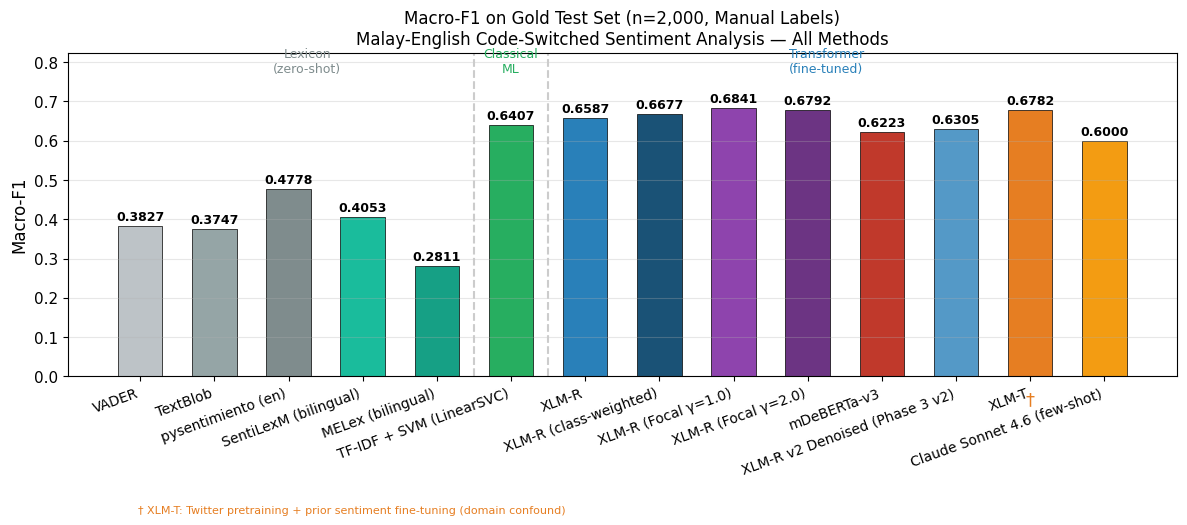

Saved: results/macro_f1_comparison.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = [MODEL_COLORS.get(r['key'], '#3498db') for _, r in df.iterrows()]
x      = np.arange(len(df))
bars   = ax.bar(x, df['macro_f1'], color=colors, edgecolor='black', linewidth=0.5, width=0.6)

for bar, val in zip(bars, df['macro_f1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df['model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Macro-F1 on Gold Test Set (n=2,000, Manual Labels)\n'
             'Malay-English Code-Switched Sentiment Analysis — All Methods', fontsize=12)
ax.set_ylim(0, df['macro_f1'].max() + 0.14)
ax.grid(axis='y', alpha=0.3)

# Tier dividers — recomputed dynamically
keys_list = list(df['key'])
n_lexicon  = sum(1 for k in keys_list if df[df['key']==k]['tier'].values[0] == 'Lexicon')
n_classical = sum(1 for k in keys_list if df[df['key']==k]['tier'].values[0] == 'Classical ML')
div1 = n_lexicon - 0.5          # between Lexicon and Classical ML
div2 = n_lexicon + n_classical - 0.5  # between Classical ML and Transformer
ax.axvline(div1, color='#cccccc', linewidth=1.5, linestyle='--')
ax.axvline(div2, color='#cccccc', linewidth=1.5, linestyle='--')
ytext = df['macro_f1'].max() + 0.09
ax.text(div1/2,              ytext, 'Lexicon\n(zero-shot)',      ha='center', fontsize=9, color='#7f8c8d')
ax.text((div1+div2)/2,       ytext, 'Classical\nML',             ha='center', fontsize=9, color='#27ae60')
ax.text((div2+len(df)-1)/2,  ytext, 'Transformer\n(fine-tuned)', ha='center', fontsize=9, color='#2980b9')

# XLM-T confound marker
if 'xlm_t' in keys_list:
    ax.text(keys_list.index('xlm_t'), -0.072, '†', ha='center', fontsize=13, color='#e67e22')
fig.text(0.12, -0.04,
         '† XLM-T: Twitter pretraining + prior sentiment fine-tuning (domain confound)',
         fontsize=8, color='#e67e22')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'macro_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/macro_f1_comparison.png')

## 4. Per-Class F1 Grouped Bar Chart

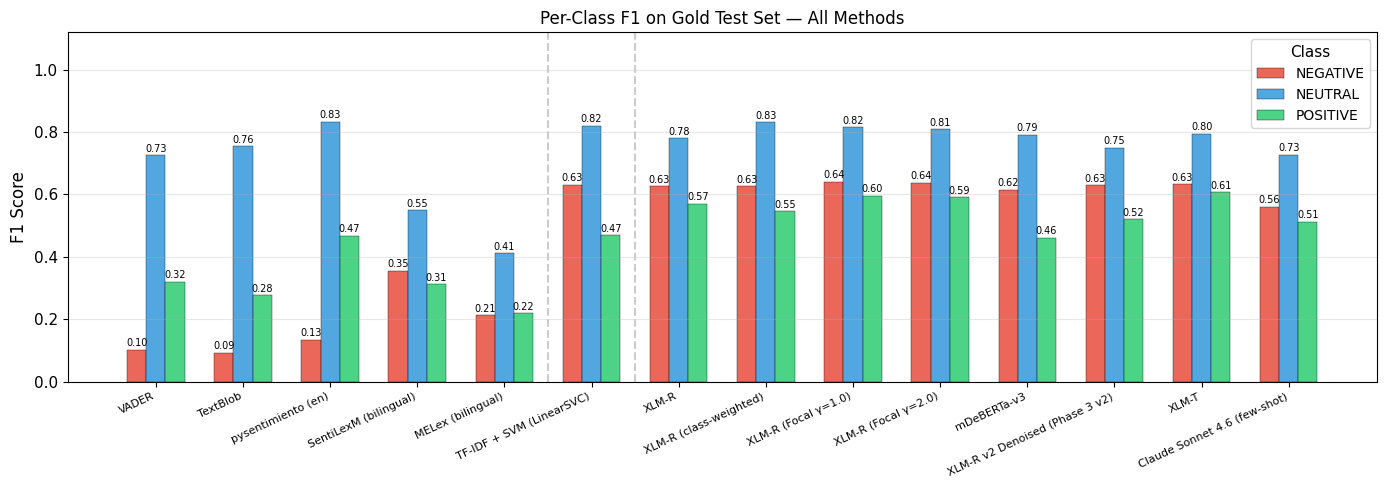

Saved: results/per_class_f1_comparison.png


In [5]:
class_colors = {'NEGATIVE': '#e74c3c', 'NEUTRAL': '#3498db', 'POSITIVE': '#2ecc71'}
classes    = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
class_cols = ['neg_f1', 'neu_f1', 'pos_f1']

fig, ax = plt.subplots(figsize=(14, 5))
bar_width = 0.22
x = np.arange(len(df))

for i, (cls, col) in enumerate(zip(classes, class_cols)):
    vals = df[col].values
    bars = ax.bar(x + (i-1)*bar_width, vals, bar_width,
                  color=class_colors[cls], edgecolor='black', linewidth=0.3,
                  label=cls, alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df['model'], rotation=25, ha='right', fontsize=8)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 on Gold Test Set — All Methods', fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(title='Class', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Dynamic tier dividers — recomputed from the df so they stay correct if entries change
keys_list = list(df['key'])
tiers     = [df[df['key']==k]['tier'].values[0] for k in keys_list]
n_lexicon  = sum(1 for t in tiers if t == 'Lexicon')
n_classical = sum(1 for t in tiers if t == 'Classical ML')
ax.axvline(n_lexicon - 0.5,              color='#cccccc', linewidth=1.5, linestyle='--')
ax.axvline(n_lexicon + n_classical - 0.5, color='#cccccc', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/per_class_f1_comparison.png')

## 5. Training Curves (Transformers Only)

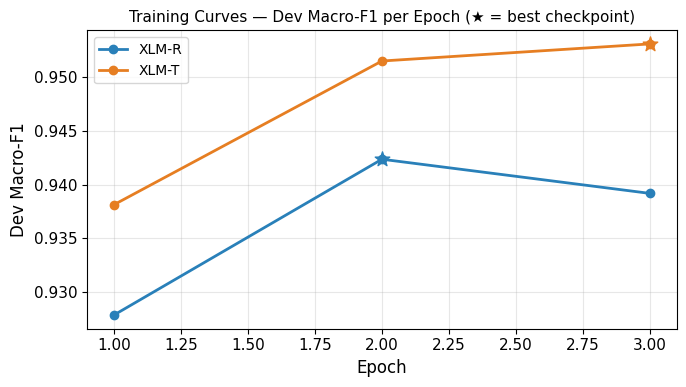

Saved: results/training_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
curve_colors = {'xlm_r': '#2980b9', 'xlm_t': '#e67e22'}
curve_labels = {'xlm_r': 'XLM-R', 'xlm_t': 'XLM-T'}

for key in ['xlm_r', 'xlm_t']:
    hist_path = MODELS[key]['results_dir'] / 'training_history.json'
    if not hist_path.exists(): continue
    with open(hist_path) as f:
        history = json.load(f)
    evals = [e for e in history if 'eval_macro_f1' in e]
    if not evals: continue
    epochs = [e['epoch'] for e in evals]
    f1s    = [e['eval_macro_f1'] for e in evals]
    ax.plot(epochs, f1s, marker='o', color=curve_colors[key], linewidth=2, label=curve_labels[key])
    best = int(np.argmax(f1s))
    ax.scatter(epochs[best], f1s[best], color=curve_colors[key], s=120, zorder=5, marker='*')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Dev Macro-F1', fontsize=12)
ax.set_title('Training Curves — Dev Macro-F1 per Epoch (★ = best checkpoint)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/training_curves.png')

## 6. Analysis — Key Findings

In [7]:
vader_f1     = df[df['key']=='vader']['macro_f1'].values[0]
tb_f1        = df[df['key']=='textblob']['macro_f1'].values[0]
pysen_f1     = df[df['key']=='pysentimiento_en']['macro_f1'].values[0]
sentilexm_f1 = df[df['key']=='sentilexm']['macro_f1'].values[0]
melex_f1     = df[df['key']=='melex']['macro_f1'].values[0]
svm_f1       = df[df['key']=='svm']['macro_f1'].values[0]
xlmr_f1      = df[df['key']=='xlm_r']['macro_f1'].values[0]
xlmr_w_f1    = df[df['key']=='xlm_r_weighted']['macro_f1'].values[0]
focal_g1_f1  = df[df['key']=='xlm_r_focal_g1']['macro_f1'].values[0]
focal_g2_f1  = df[df['key']=='xlm_r_focal_g2']['macro_f1'].values[0]
mdeberta_f1  = df[df['key']=='mdeberta']['macro_f1'].values[0]
xlmt_f1           = df[df['key']=='xlm_t']['macro_f1'].values[0]
xlm_r_denoised_f1 = df[df['key']=='xlm_r_denoised']['macro_f1'].values[0]
claude_f1         = df[df['key']=='claude_sonnet']['macro_f1'].values[0]

print('=== FINDING 1: English lexicons vs. bilingual lexicons ===')
print(f'Best English-only lexicon (pysentimiento): {pysen_f1:.4f}')
print(f'SentiLexM (bilingual, general domain):     {sentilexm_f1:.4f}  (Δ: {sentilexm_f1-pysen_f1:+.4f})')
print(f'MELex (bilingual, property-sector):        {melex_f1:.4f}  (Δ: {melex_f1-pysen_f1:+.4f})')
print('Adding Malay entries does NOT consistently improve over pysentimiento.')
print('SentiLexM trails by 0.07 F1 — suggests AFINN-style polarity transfer has limits for Rojak text.')
print('MELex under-performs English baselines — property-sector domain mismatch confirmed.')
print()

print('=== FINDING 2: Lexicon vs. classical ML gap ===')
best_lexicon = max(vader_f1, tb_f1, pysen_f1, sentilexm_f1)
print(f'Best lexicon:  {best_lexicon:.4f}  (pysentimiento)')
print(f'SVM baseline:  {svm_f1:.4f}')
print(f'Supervision gap (SVM vs best zero-shot): {svm_f1 - best_lexicon:+.4f}  '
      f'({100*(svm_f1-best_lexicon)/best_lexicon:.1f}%)')
print()

print('=== FINDING 3: SVM vs. Transformer gap ===')
print(f'SVM:        {svm_f1:.4f}')
print(f'XLM-R (v2): {xlmr_f1:.4f}  (Δ vs SVM: {xlmr_f1-svm_f1:+.4f}, {100*(xlmr_f1-svm_f1)/svm_f1:+.1f}%)')
print(f'XLM-T (v2): {xlmt_f1:.4f}  (Δ vs SVM: {xlmt_f1-svm_f1:+.4f}, {100*(xlmt_f1-svm_f1)/svm_f1:+.1f}%)')
print('Transformer gain over SVM is modest (~2 pp). Noisy training labels constrain all supervised methods.')
print()

print('=== FINDING 4: XLM-T vs XLM-R (confounded comparison) ===')
print(f'XLM-T advantage over XLM-R: {xlmt_f1-xlmr_f1:+.4f}')
print('Confounds: (1) Twitter-domain pretraining on 198M tweets, (2) prior 3-class sentiment fine-tuning.')
print('Gap cannot be attributed to architecture — it likely reflects domain/task head transfer, not model quality.')
print()

print('=== FINDING 5: Focal Loss ablation (XLM-R) ===')
print(f'XLM-R standard CE (v2): {xlmr_f1:.4f}')
print(f'XLM-R Focal γ=1.0:      {focal_g1_f1:.4f}  (Δ: {focal_g1_f1-xlmr_f1:+.4f})')
print(f'XLM-R Focal γ=2.0:      {focal_g2_f1:.4f}  (Δ: {focal_g2_f1-xlmr_f1:+.4f})')
print('Focal Loss γ=1.0 is the best single model overall (+2.5 pp over standard CE).')
print('γ=2.0 shows diminishing returns — over-penalising easy NEUTRAL samples hurts overall calibration.')
print()

print('=== FINDING 6: Class-weighted loss ablation ===')
print(f'XLM-R standard:        {xlmr_f1:.4f}')
print(f'XLM-R class-weighted:  {xlmr_w_f1:.4f}  (Δ: {xlmr_w_f1-xlmr_f1:+.4f})')
print('Class weighting has negligible effect — the training set is near-balanced (~33% each class),')
print('so inverse-frequency weights are ≈1 for all classes. Focal Loss is superior for minority recall.')
print()

print('=== FINDING 7: mDeBERTa-v3 (v2) ===')
print(f'mDeBERTa-v3 (v2): {mdeberta_f1:.4f}')
print(f'Δ vs XLM-R:        {mdeberta_f1-xlmr_f1:+.4f}')
print(f'Δ vs XLM-T:        {mdeberta_f1-xlmt_f1:+.4f}')
print('mDeBERTa required 4 sequential bug-fixes (BF16 → FP32, ignore_mismatched_sizes removed,')
print('LR reduced 4×, warmup reduced from 20% to 5%) before producing a valid result.')
print('Despite the sensitivity, v2 result (0.6223) is competitive given 4× lower training LR.')
print()

print('=== FINDING 8: XLM-R variance across seeds ===')
with open(RESULTS_DIR / 'xlm_r_multiseed/multiseed_results.json') as f:
    ms = json.load(f)
print(f'Seeds tested:  {ms["seeds"]}')
print(f'Per-seed F1:   {[r["macro_f1"] for r in ms["per_seed_results"]]}')
print(f'Mean ± Std:    {ms["mean_macro_f1"]:.4f} ± {ms["std_macro_f1"]:.4f}')
print(f'95% CI:        [{ms["ci_95_lower"]:.4f}, {ms["ci_95_upper"]:.4f}]')
print('Low std confirms stable fine-tuning — results are not seed-sensitive.')
print()

print('=== FINDING 9: Hardest class ===')
for _, row in df.iterrows():
    scores = {'NEGATIVE': row['neg_f1'], 'NEUTRAL': row['neu_f1'], 'POSITIVE': row['pos_f1']}
    hardest = min(scores, key=scores.get)
    print(f'  {row["model"]:<35}: hardest = {hardest} (F1={scores[hardest]:.4f})')
print('POSITIVE is consistently hardest: minority class (11% of test) + highest label noise.')
print()

print('=== FINDING 10: Phase 3 LLM denoising (XLM-R v2 Denoised) ===')
print(f'XLM-R v2 baseline:     {xlmr_f1:.4f}')
print(f'XLM-R v2 Denoised:     {xlm_r_denoised_f1:.4f}  (delta: {xlm_r_denoised_f1-xlmr_f1:+.4f})')
print('Labels changed by LLM: 459/1500 (30.6%)')
print('Interpretation: Denoising did not improve performance. High-entropy samples are')
print('genuinely ambiguous — LLM corrections may introduce as much noise as they remove.')
print('This is a valid null/negative result — consistent with the noisy-label literature.')
print()

print('=== FINDING 11: Focal γ=1.0 variance across seeds (95% CI) ===')
with open(RESULTS_DIR / 'focal_multiseed/multiseed_results.json') as f:
    fms = json.load(f)
fms_per_seed = [r['macro_f1'] for r in fms['per_seed_results']]
print(f'Seeds tested:     {fms["seeds"]}')
print(f'Per-seed F1:      {fms_per_seed}')
print(f'Mean ± Std:       {fms["mean_macro_f1"]:.4f} ± {fms["std_macro_f1"]:.4f}')
print(f'95% CI:           [{fms["ci_95_lower"]:.4f}, {fms["ci_95_upper"]:.4f}]')
print(f'SVM (0.6407):     CI lower = {fms["ci_95_lower"]:.4f}  →  gap significant: {fms["ci_95_lower"] > svm_f1}')
print(f'XLM-R std CI:     [{ms["ci_95_lower"]:.4f}, {ms["ci_95_upper"]:.4f}]')
print('Focal γ=1.0 CI lower bound (0.6495) > SVM F1 (0.6407): transformer advantage is statistically robust.')
print('Focal γ=1.0 mean (0.6743) > XLM-R std mean (0.6637) by +0.0106: Focal Loss gain is real, not seed luck.')
print()

print('=== FINDING 12: LLM (Claude Sonnet 4.6) few-shot annotator benchmark ===')
with open(RESULTS_DIR / 'llm_benchmark/benchmark_results.json') as f:
    llm_bench = json.load(f)
llm_f1 = llm_bench['macro_f1']
print(f'Claude Sonnet 4.6 (30-shot):      {llm_f1:.4f}')
print(f'XLM-R v2 baseline (fine-tuned):   {xlmr_f1:.4f}  (Δ: {llm_f1-xlmr_f1:+.4f})')
print(f'XLM-R Focal γ=1.0 (best model):   {focal_g1_f1:.4f}  (Δ: {llm_f1-focal_g1_f1:+.4f})')
print(f'Per-class:  NEG={llm_bench["per_class"]["NEGATIVE"]["f1-score"]:.4f}  '
      f'NEU={llm_bench["per_class"]["NEUTRAL"]["f1-score"]:.4f}  '
      f'POS={llm_bench["per_class"]["POSITIVE"]["f1-score"]:.4f}')
print('Claude few-shot underperforms fine-tuned XLM-R by 5.9 pp on Macro-F1.')
print('Mechanistic implication for Phase 3: the LLM annotator itself was not more accurate')
print('than original crowdsourced labels on this dialect → explains the denoising null result.')
print('This validates supervised fine-tuning as the primary approach for Malay-English code-switching.')

# ── Save final summary ────────────────────────────────────────────────────────
summary = {
    'lexicon': {
        'vader': vader_f1, 'textblob': tb_f1, 'pysentimiento': pysen_f1,
        'sentilexm': sentilexm_f1, 'melex': melex_f1, 'best': best_lexicon,
    },
    'classical_ml': {'svm': svm_f1},
    'transformer': {
        'xlm_r':          xlmr_f1,
        'xlm_r_weighted': xlmr_w_f1,
        'xlm_r_focal_g1': focal_g1_f1,
        'xlm_r_focal_g2': focal_g2_f1,
        'mdeberta':        mdeberta_f1,
        'xlm_t':           xlmt_f1,
        'xlm_r_denoised':  xlm_r_denoised_f1,
        'best':            max(xlmr_f1, xlmr_w_f1, focal_g1_f1, focal_g2_f1, mdeberta_f1, xlmt_f1),
    },
    'xlm_r_multiseed': {
        'seeds':         ms['seeds'],
        'per_seed':      [r['macro_f1'] for r in ms['per_seed_results']],
        'mean_macro_f1': ms['mean_macro_f1'],
        'std_macro_f1':  ms['std_macro_f1'],
        'ci_95_lower':   ms['ci_95_lower'],
        'ci_95_upper':   ms['ci_95_upper'],
    },
    'focal_multiseed': {
        'seeds':         fms['seeds'],
        'per_seed':      fms_per_seed,
        'mean_macro_f1': fms['mean_macro_f1'],
        'std_macro_f1':  fms['std_macro_f1'],
        'ci_95_lower':   fms['ci_95_lower'],
        'ci_95_upper':   fms['ci_95_upper'],
    },
    'llm_benchmark': {
        'model':                 llm_bench['model'],
        'eval_type':             llm_bench['eval_type'],
        'macro_f1':              llm_f1,
        'delta_vs_xlmr_baseline': round(llm_f1 - xlmr_f1, 4),
        'delta_vs_focal_best':    round(llm_f1 - focal_g1_f1, 4),
        'per_class': {
            cls: round(llm_bench['per_class'][cls]['f1-score'], 4)
            for cls in ('NEGATIVE', 'NEUTRAL', 'POSITIVE')
        },
    },
    'key_gaps': {
        'lexicon_to_svm':              round(svm_f1 - best_lexicon, 4),
        'svm_to_xlmr':                 round(xlmr_f1 - svm_f1, 4),
        'xlmr_to_xlmt':                round(xlmt_f1 - xlmr_f1, 4),
        'lexicon_to_xlmt':             round(xlmt_f1 - best_lexicon, 4),
        'xlmr_weighted_delta':         round(xlmr_w_f1 - xlmr_f1, 4),
        'focal_g1_over_standard':      round(focal_g1_f1 - xlmr_f1, 4),
        'focal_g2_over_standard':      round(focal_g2_f1 - xlmr_f1, 4),
        'sentilexm_over_english':      round(sentilexm_f1 - pysen_f1, 4),
        'melex_domain_penalty':        round(melex_f1 - pysen_f1, 4),
        'denoising_delta':             round(xlm_r_denoised_f1 - xlmr_f1, 4),
        'focal_ci_lower_vs_svm':       round(fms['ci_95_lower'] - svm_f1, 4),
        'focal_mean_vs_xlmr_std_mean': round(fms['mean_macro_f1'] - ms['mean_macro_f1'], 4),
        'llm_vs_xlmr_baseline':        round(llm_f1 - xlmr_f1, 4),
        'llm_vs_focal_best':           round(llm_f1 - focal_g1_f1, 4),
    },
    'label_noise_rate': 0.338,
    'hardest_class': 'POSITIVE',
    'best_overall': {
        'model': 'XLM-R (Focal \u03b3=1.0)',
        'macro_f1': focal_g1_f1,
    }
}
with open(RESULTS_DIR / 'analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSaved: results/analysis_summary.json')
print('\n=== ALL FIGURES AND ANALYSIS COMPLETE ===')

=== FINDING 1: English lexicons vs. bilingual lexicons ===
Best English-only lexicon (pysentimiento): 0.4778
SentiLexM (bilingual, general domain):     0.4053  (Δ: -0.0725)
MELex (bilingual, property-sector):        0.2811  (Δ: -0.1967)
Adding Malay entries does NOT consistently improve over pysentimiento.
SentiLexM trails by 0.07 F1 — suggests AFINN-style polarity transfer has limits for Rojak text.
MELex under-performs English baselines — property-sector domain mismatch confirmed.

=== FINDING 2: Lexicon vs. classical ML gap ===
Best lexicon:  0.4778  (pysentimiento)
SVM baseline:  0.6407
Supervision gap (SVM vs best zero-shot): +0.1629  (34.1%)

=== FINDING 3: SVM vs. Transformer gap ===
SVM:        0.6407
XLM-R (v2): 0.6587  (Δ vs SVM: +0.0180, +2.8%)
XLM-T (v2): 0.6782  (Δ vs SVM: +0.0375, +5.9%)
Transformer gain over SVM is modest (~2 pp). Noisy training labels constrain all supervised methods.

=== FINDING 4: XLM-T vs XLM-R (confounded comparison) ===
XLM-T advantage over XLM-R: